# HỆ THỐNG KIỂM TRA CHỨNG TỪ GIAO NHẬN KIDO (E2E PIPELINE)
### Hợp Nhất 4 Tầng: Chuẩn Hóa Ảnh ➔ Phân Loại Biểu Mẫu ➔ Định Vị Quy Chuẩn ➔ Kiểm Tra Chữ Ký & Con Dấu Mộc Đỏ
> **Trạng thái:** mọi phán quyết trong notebook này là **kết quả chạy thật** của `KidoDocumentPipeline` trong từng cell — markdown chỉ mô tả kịch bản và **contract kỳ vọng**, không ghi trước kết quả. Chỉ số độ chính xác từng tầng xem artifact tương ứng (AGENTS.md mục 0).
>
> **Contract hiện tại (AGENTS.md 9.10.B):** `HOA_DON` → `UNMAPPED` / ABSTAIN (`zone_status = HOA_DON_ZONE_DEFERRED` — vùng ký hóa đơn hoãn vì cần template theo chi nhánh/kênh). `LOADING_PLAN` dùng zone động Tầng 3b + **Tầng 4 ver2** (`engine = "v2"`; biểu mẫu preset tĩnh dùng v1): `PAGE_1_NO_SIGNATURES` → `TRANG_1_CHUA_KY` / HOP_LE; zone ABSTAIN → `CHUA_CHUAN_HOA_VUNG_KY` / ABSTAIN. Trạng thái ngoài bảng ánh xạ → `REVIEW_REQUIRED`.

---

## 1. Bức Tranh Toàn Cảnh & Quy Trình 4 Tầng Liên Hoàn

Hệ thống nhận đầu vào là **1 bức ảnh chụp/scan bất kỳ** của chứng từ giao nhận KIDO và tự động thực hiện 2 nhiệm vụ cốt lõi:
1. **Phân loại loại chứng từ** (`doc_type`), xác định kênh phân phối / hệ thống siêu thị đối tác, và bóc tách các số chứng từ nghiệp vụ quan trọng (`invoice_no`, `po_no`, `shipment_id`, `pxk_no`, `transfer_order_no`).
2. **Kiểm tra xem con dấu mộc và chữ ký có đầy đủ không**: Đối chiếu với quy chuẩn biểu mẫu KIDO, kiểm tra sự hiện diện của mộc đỏ công ty, mộc vuông tiếp nhận siêu thị và chữ ký sống của các bên liên quan, đưa ra phán quyết nghiệp vụ rõ ràng (**ĐỦ DẤU / THIẾU DẤU / CHƯA KÝ**).

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│     TẦNG 1      │     │     TẦNG 2      │     │     TẦNG 3      │     │     TẦNG 4      │
│  Chuẩn Hóa A4   │ ──> │    Phân Loại    │ ──> │ Ánh Xạ Vị Trí   │ ──> │ Kiểm Định Mộc & │
│ Cân Sáng & Màu  │     │ Bóc Tách Trường │     │ Quy Chuẩn KIDO  │     │ Chữ Ký (HSV+BW) │
└─────────────────┘     └─────────────────┘     └─────────────────┘     └─────────────────┘
```

In [1]:
import os
import sys
import time
from pathlib import Path

# Cấu hình encoding và đường dẫn
sys.path.insert(0, os.getcwd())
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Cấu hình Matplotlib hiển thị đẹp mắt, không dùng directive lỗi thời %matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Nạp module Pipeline hợp nhất
from tools.kido_pipeline import KidoDocumentPipeline, KidoPipelineConfig, draw_visual_inspection

pipeline = KidoDocumentPipeline()
print("✓ Đã khởi tạo thành công KidoDocumentPipeline (Hợp nhất 4 tầng)")
print(f"✓ Danh mục quy chuẩn nạp sẵn: {len(pipeline.signature_catalog)} loại biểu mẫu KIDO")

✓ Đã khởi tạo thành công KidoDocumentPipeline (Hợp nhất 4 tầng)
✓ Danh mục quy chuẩn nạp sẵn: 14 loại biểu mẫu KIDO


In [2]:
def display_audit_dashboard(result, title=None):
    """
    Hiển thị Dashboard trực quan hóa toàn diện kết quả kiểm tra chứng từ:
    - Bảng thông tin tổng quan nghiệp vụ (Loại biểu mẫu, Hệ thống, Số HĐ/PO, Phán quyết)
    - Ảnh chuẩn hóa A4 kèm Bounding Box màu sắc:
      • Xanh lá (#00C800): ĐÃ KÝ / ĐÃ ĐÓNG DẤU
      • Đỏ (#EF4444): THIẾU BẮT BUỘC
      • Vàng (#F59E0B): TÙY CHỌN (Optional)
    - Gallery Crop Zoom cận cảnh từng ô chữ ký & con dấu mộc
    """
    status = result.get("status")
    file_name = result.get("file_name", "Document")
    elapsed = result.get("elapsed_sec", 0.0)
    
    if status == "YEU_CAU_CHUP_LAI":
        # Hiển thị banner cảnh báo gác cổng Tầng 1
        print("=" * 80)
        print(f"❌ [GÁC CỔNG TẦNG 1] TỪ CHỐI CHỨNG TỪ: {file_name}")
        print("=" * 80)
        print("Trạng thái: YÊU CẦU CHỤP LẠI (Ảnh không đạt tiêu chuẩn kỹ thuật)")
        for rj in result.get("stage1", {}).get("rejects", []):
            print(f" • Lý do: {rj}")
        for wn in result.get("stage1", {}).get("warns", []):
            print(f" • Cảnh báo: {wn}")
        print(f"Thời gian kiểm định dừng sớm: {elapsed:.2f}s")
        print("=" * 80 + "\n")
        return

    # Thông tin Tầng 2 & Tầng 4
    s2 = result.get("stage2", {})
    s4 = result.get("stage4", {})
    doc_type_vi = s2.get("doc_type_vi", s2.get("doc_type"))
    system = s2.get("system", "COMMON")
    key_fields = s2.get("key_fields", {})
    verdict_title = s4.get("verdict_title", "CHƯA XÁC ĐỊNH")
    verdict_message = s4.get("verdict_message", "")
    overall_verdict = s4.get("overall_verdict", "")
    target_results = s4.get("target_results", [])

    # In thông tin kiểm toán dạng văn bản có cấu trúc
    header_title = title or f"KẾT QUẢ ĐỐI SOÁT CHỨNG TỪ: {file_name}"
    print("=" * 90)
    print(f"📋 {header_title.upper()}")
    print("=" * 90)
    print(f"1. PHÂN LOẠI CHỨNG TỪ:")
    print(f"   • Tên biểu mẫu:      {doc_type_vi} ({s2.get('doc_type')})")
    print(f"   • Hệ thống / Đối tác: {system}")
    print(f"   • Số Hóa đơn:        {key_fields.get('invoice_no') or 'Không có'}")
    print(f"   • Số Đơn hàng (PO):  {key_fields.get('po_no') or 'Không có'}")
    print(f"   • Mã chuyến xe (SAP): {key_fields.get('shipment_id') or 'Không có'}")
    print(f"   • Phiếu xuất kho:    {key_fields.get('pxk_no') or key_fields.get('transfer_order_no') or 'Không có'}")
    print("-" * 90)
    print(f"2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:")
    print(f"   • Phán quyết:        {verdict_title}")
    print(f"   • Nội dung kết luận: {verdict_message}")
    print(f"   • Action vận hành:   {s4.get('action')}  | zone_status: {result.get('stage3', {}).get('zone_status')}  | engine Tầng 4: {result.get('engine')}")
    if s4.get("abstain_reason"):
        print(f"   • Lý do ABSTAIN:     {s4.get('abstain_reason')}")
    print(f"   • Định dạng tài liệu: {s4.get('document_modality')} | Vị trí đạt: {s4.get('detected_required_targets')}/{s4.get('total_required_targets')} bắt buộc")
    print("-" * 90)
    print(f"3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:")
    for idx, tr in enumerate(target_results):
        det_icon = "✓ ĐÃ CÓ" if tr.get("detected") else ("✗ THIẾU" if tr.get("required") else "○ KHÔNG CÓ")
        req_str = "Bắt buộc" if tr.get("required") else "Tùy chọn"
        print(f"   [{idx+1}] {tr.get('role'):<30} | {det_icon:<10} | {req_str:<10} | Mực: {tr.get('ink_type'):<25} | Engine: {tr.get('engine')}")
    print(f"   (Thời gian xử lý E2E toàn bộ 4 tầng: {elapsed:.2f} giây)")
    print("=" * 90 + "\n")

    # Vẽ trực quan hóa hình ảnh
    annotated_img, crops_list = draw_visual_inspection(result, max_display_height=1100)
    
    # Xác định bố cục đồ họa
    n_crops = len(crops_list)
    if n_crops == 0:
        fig, ax = plt.subplots(1, 1, figsize=(8, 10))
        ax.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{doc_type_vi}\n{verdict_title}", fontsize=13, fontweight='bold', color='navy')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        return

    fig = plt.figure(figsize=(16, max(9, n_crops * 2.8)))
    gs = fig.add_gridspec(max(2, n_crops), 2, width_ratios=[1.3, 1.0])

    # Panel trái: Ảnh toàn trang A4 kèm Bounding Boxes
    ax_main = fig.add_subplot(gs[:, 0])
    ax_main.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    
    status_color = '#008000' if 'DAT_CHUAN' in overall_verdict else ('#C80000' if 'THIEU' in overall_verdict or 'CHUA_KY' in overall_verdict else '#4B5563')
    ax_main.set_title(f"ẢNH CHỨNG TỪ A4 (2200px) - PHÁT HIỆN VÙNG KÝ & MỘC\n{verdict_title}", 
                      fontsize=12, fontweight='bold', color=status_color, pad=12)
    ax_main.axis('off')

    # Panel phải: Gallery zoom cận cảnh từng ô
    for i, (role, crop_bgr, t_res) in enumerate(crops_list):
        ax_crop = fig.add_subplot(gs[i, 1])
        if crop_bgr is not None and crop_bgr.size > 0:
            ax_crop.imshow(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        ax_crop.axis('off')
        
        det = t_res.get('detected', False)
        req = t_res.get('required', True)
        bg_col = '#10B981' if det else ('#EF4444' if req else '#F59E0B')
        status_lbl = "ĐÃ PHÁT HIỆN" if det else ("CHƯA CÓ (BẮT BUỘC)" if req else "CHƯA CÓ (TÙY CHỌN)")
        
        info_title = f"{role}\n[{status_lbl}] - Mực: {t_res.get('ink_type')} | Tin cậy: {t_res.get('confidence', 0):.2f}"
        ax_crop.set_title(info_title, fontsize=9.5, fontweight='bold', color=bg_col, loc='left', pad=6)

    plt.tight_layout()
    plt.show()

## 2. Thử Nghiệm Nhanh Trên 1 Ảnh Tùy Chọn (Single-Image Quick Run)
Bạn chỉ cần truyền đường dẫn của bất kỳ ảnh nào vào biến `IMAGE_PATH` dưới đây. Pipeline sẽ tự động thực thi liên hoàn cả 4 tầng và hiển thị Dashboard đầy đủ:

📋 DEMO TRỰC QUAN HÓA NHANH 1 ẢNH
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Bảng kê xếp hàng (Loading Plan) (LOADING_PLAN)
   • Hệ thống / Đối tác: GT
   • Số Hóa đơn:        Không có
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): Không có
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        ĐẠT CHUẨN (BẢN GỐC CÓ MÀU)
   • Nội dung kết luận: Chứng từ có đầy đủ 3/3 vị trí chữ ký & con dấu mộc đỏ/xanh chuẩn màu thực tế.
   • Action vận hành:   DUYET  | zone_status: TABLE_BOTTOM_DETECTED  | engine Tầng 4: v2
   • Định dạng tài liệu: TRUE_COLOR | Vị trí đạt: 3/3 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   [1] Người lập phiếu                | ✓ ĐÃ CÓ    | Tùy chọn   | Mực: blue_ink                  | Engine: V2_SIGNATURE_MM
   [2] Trưởng BP Kho / Nhóm tr

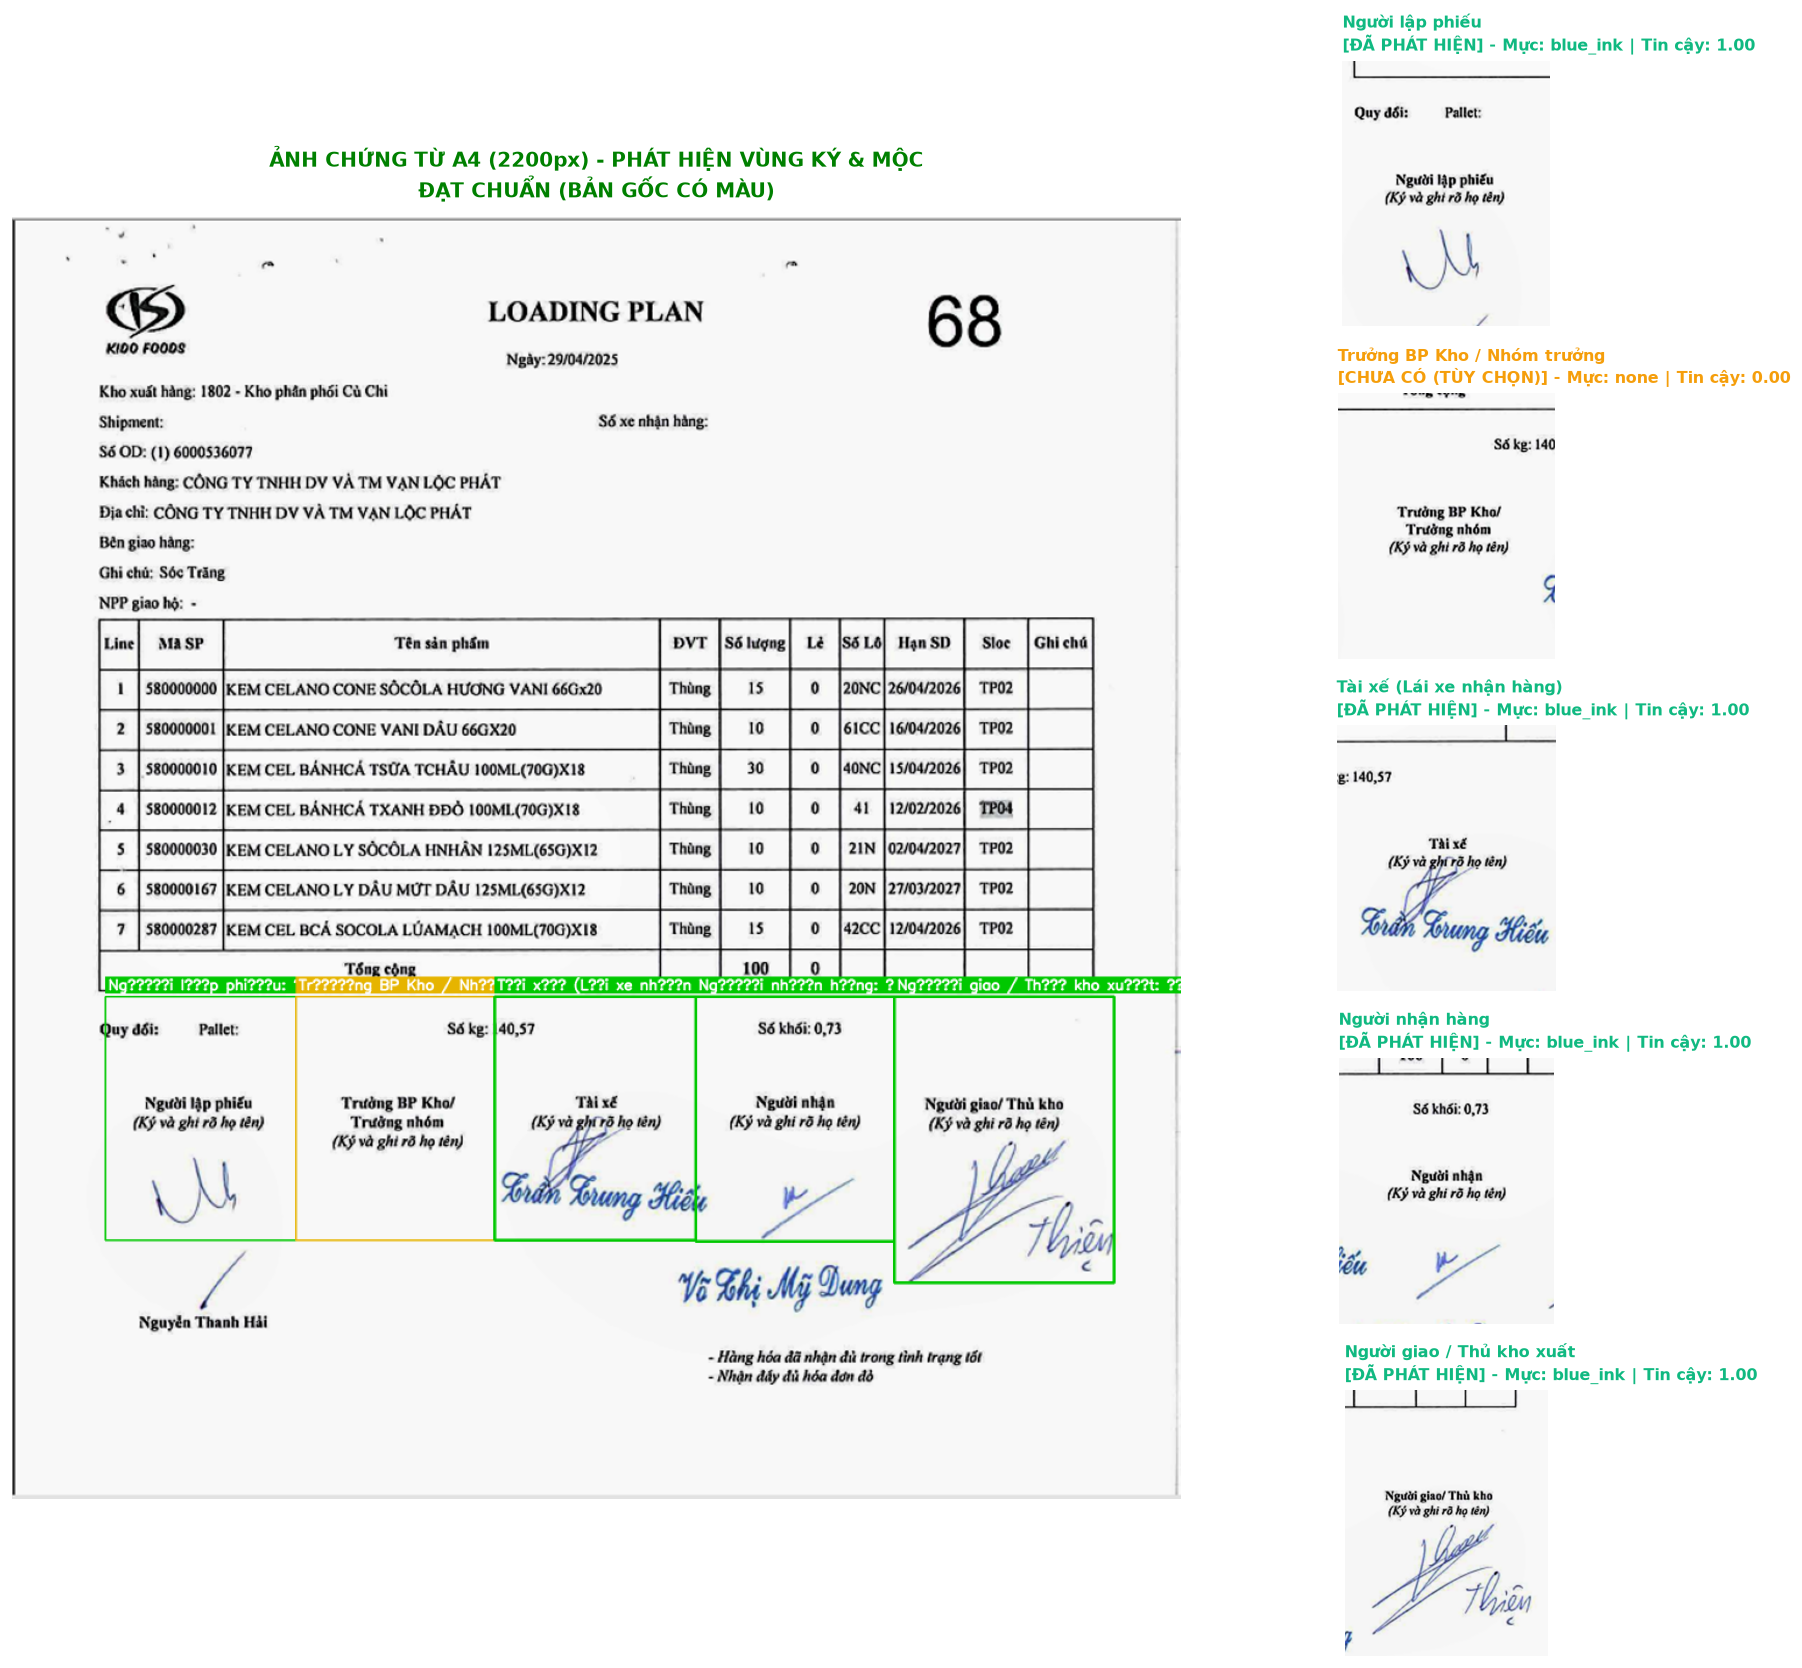

In [3]:
# Đường dẫn ảnh bạn muốn kiểm tra (thay đổi tùy ý)
IMAGE_PATH = "output/form_samples/Loading_Plan2.1__0.png"

# Thực hiện toàn bộ 4 tầng chỉ với 1 dòng lệnh
result = pipeline.process_document(IMAGE_PATH)

# Hiển thị trực quan Dashboard kiểm toán
display_audit_dashboard(result, title="DEMO TRỰC QUAN HÓA NHANH 1 ẢNH")

---
## 3. Khảo Sát Chi Tiết 6 Kịch Bản Nghiệp Vụ Thực Tế

### Ca 1: Hóa đơn GTGT — vùng ký HOÃN (UNMAPPED / ABSTAIN)
- **Tầng 1–2:** chuẩn hóa A4, phân loại `HOA_DON` và bóc tách số hóa đơn (giá trị in ở output, không ghi trước).
- **Tầng 3b:** vùng ký hóa đơn **hoãn** — quy chuẩn ký/mộc khác nhau theo từng chi nhánh/kênh, cần template riêng. Pipeline **không** gọi detector hóa đơn và **không** fallback về preset tĩnh.
- **Tầng 4 (contract kỳ vọng):** không chấm target nào → `UNMAPPED` / action `ABSTAIN`, `zone_status = HOA_DON_ZONE_DEFERRED`. Chứng từ phải chuyển người kiểm tra.

📋 CA 1: HÓA ĐƠN - VÙNG KÝ HOÃN (UNMAPPED / ABSTAIN)
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Hóa đơn giá trị gia tăng / Bán lẻ (HOA_DON)
   • Hệ thống / Đối tác: GT
   • Số Hóa đơn:        00044085
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): Không có
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        CHƯA CÓ CẤU HÌNH VỊ TRÍ (UNMAPPED)
   • Nội dung kết luận: Không kết luận chữ ký/mộc: HOA_DON zone hoãn — cần template theo chi nhánh/kênh (system=GT)
   • Action vận hành:   ABSTAIN  | zone_status: HOA_DON_ZONE_DEFERRED  | engine Tầng 4: None
   • Lý do ABSTAIN:     HOA_DON zone hoãn — cần template theo chi nhánh/kênh (system=GT)
   • Định dạng tài liệu: TRUE_COLOR | Vị trí đạt: 0/0 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   (Thời gian xử lý E2

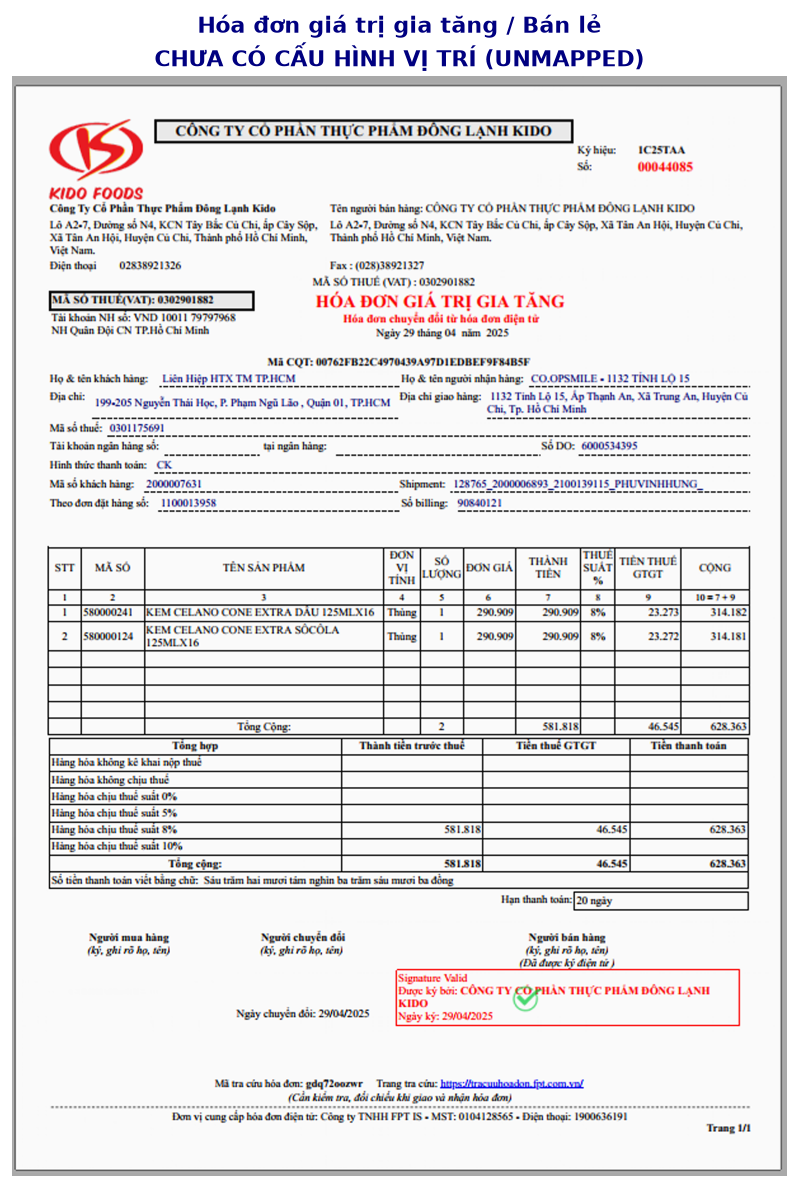

In [4]:
res_case1 = pipeline.process_document("output/form_samples/Hoadon2.2__0.png")
display_audit_dashboard(res_case1, title="CA 1: HÓA ĐƠN - VÙNG KÝ HOÃN (UNMAPPED / ABSTAIN)")

### Ca 2: Phiếu giao hàng siêu thị (preset tĩnh, Tầng 4 v1)
- **Đặc điểm:** phiếu giao hàng có mộc vuông tiếp nhận của siêu thị.
- **Tầng 4:** v1 chọn engine theo modality đo được (`TRUE_COLOR` → Engine A HSV; `PHOTOCOPY_BW` → Engine B hình thái học). Modality và phán quyết **in ở output**. Lưu ý: Engine B có FP đã biết do đường kẻ bảng (AGENTS.md 7.E).

📋 CA 2: PHIẾU GIAO HÀNG SIÊU THỊ (PRESET TĨNH, V1)
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Phiếu nhập kho kiêm tiếp nhận (PNK) (PHIEU_NHAP_KHO)
   • Hệ thống / Đối tác: MT_WINMART
   • Số Hóa đơn:        Không có
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): Không có
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        ĐẠT CHUẨN (BẢN PHOTO ĐEN TRẮNG)
   • Nội dung kết luận: Chứng từ photo đã ký & đóng dấu đầy đủ 3/3 vị trí (xác thực qua viền dấu & nét bút).
   • Action vận hành:   DUYET  | zone_status: None  | engine Tầng 4: v1
   • Định dạng tài liệu: PHOTOCOPY_BW | Vị trí đạt: 3/3 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   [1] Bên giao                       | ✓ ĐÃ CÓ    | Bắt buộc   | Mực: bw_stroke                 | Engine: ENGINE_B_BW
   [2

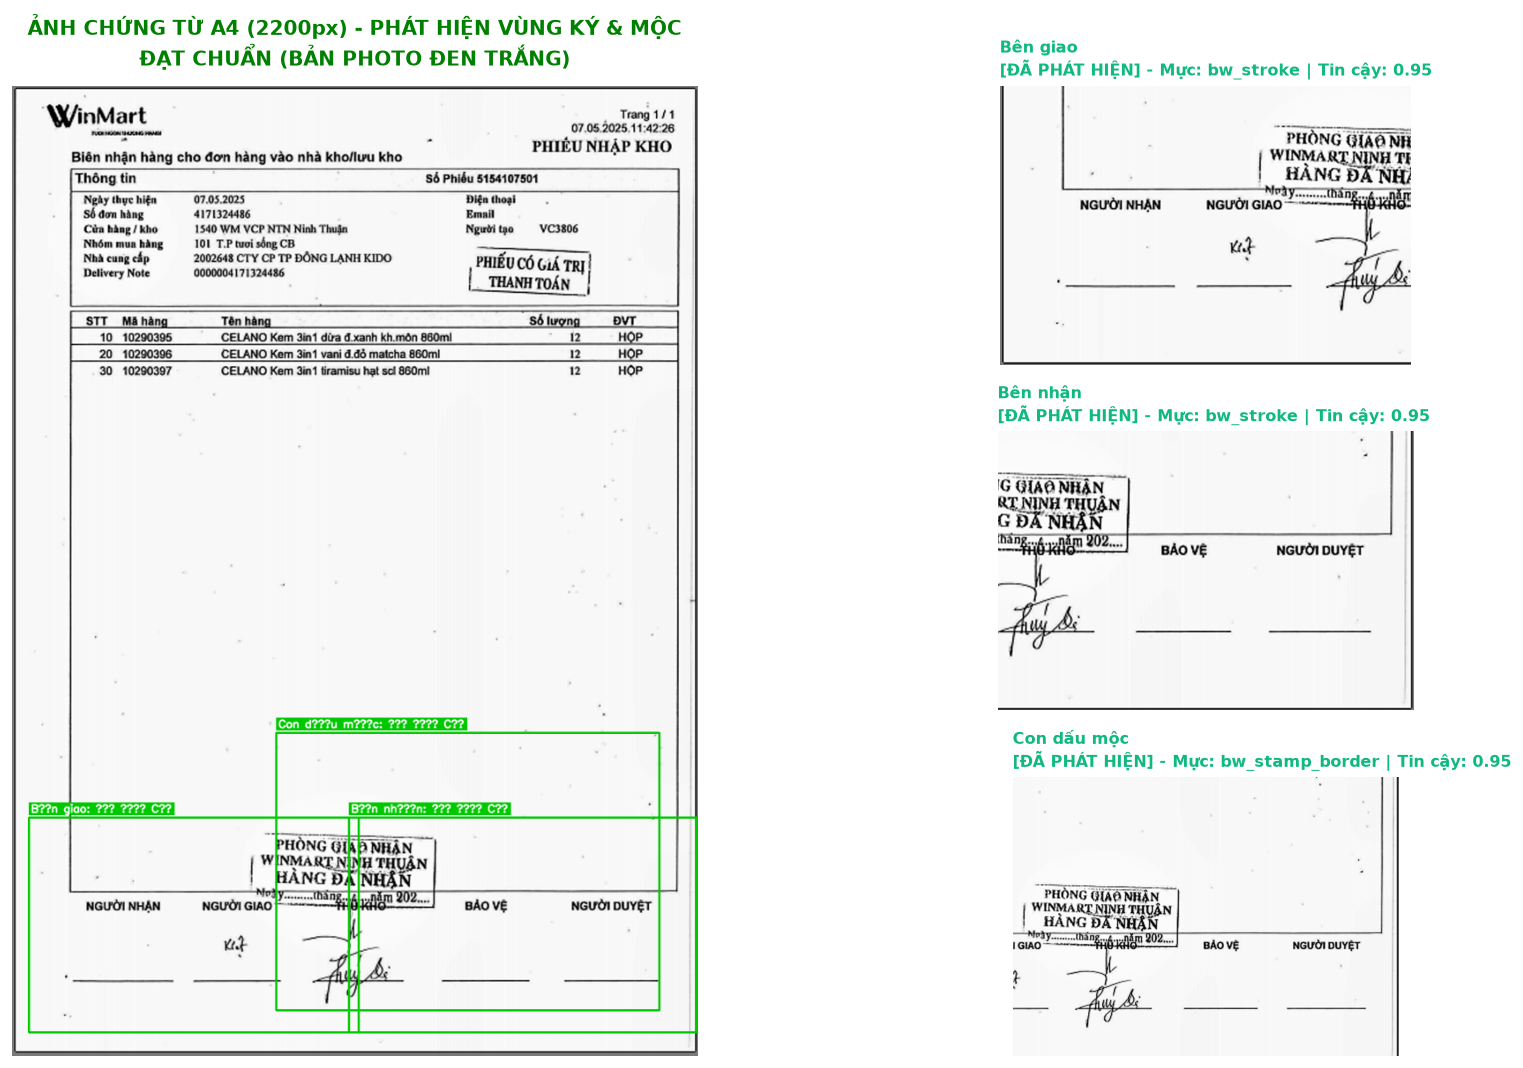

In [5]:
res_case2 = pipeline.process_document("output/form_samples/PGH3.6__0.png")
display_audit_dashboard(res_case2, title="CA 2: PHIẾU GIAO HÀNG SIÊU THỊ (PRESET TĨNH, V1)")

### Ca 3: Biên bản nợ hàng — kiểm tra thiếu một phần
- **Mục đích:** minh họa phân tách vị trí đạt / thiếu. Nếu chỉ một phần vị trí `required` có chữ ký/mộc, contract là `THIEU_MOT_SO_CHU_KY` / action `CANH_BAO` kèm danh sách vai trò thiếu.
- Phán quyết thực tế của ảnh này **in ở output**, không ghi trước.

📋 CA 3: BIÊN BẢN NỢ HÀNG
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Biên bản nợ hàng (BB_NO_HANG)
   • Hệ thống / Đối tác: COMMON
   • Số Hóa đơn:        Không có
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): Không có
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        CẢNH BÁO: THIẾU CHỮ KÝ / DẤU MỘC
   • Nội dung kết luận: Mới phát hiện 2/3 vị trí bắt buộc. Còn thiếu: Bên giao.
   • Action vận hành:   CANH_BAO  | zone_status: None  | engine Tầng 4: v1
   • Định dạng tài liệu: TRUE_COLOR | Vị trí đạt: 2/3 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   [1] Bên giao                       | ✗ THIẾU    | Bắt buộc   | Mực: none                      | Engine: ENGINE_A_COLOR
   [2] Bên nhận                       | ✓ ĐÃ CÓ    | Bắt buộc   | Mực: black_ink_o

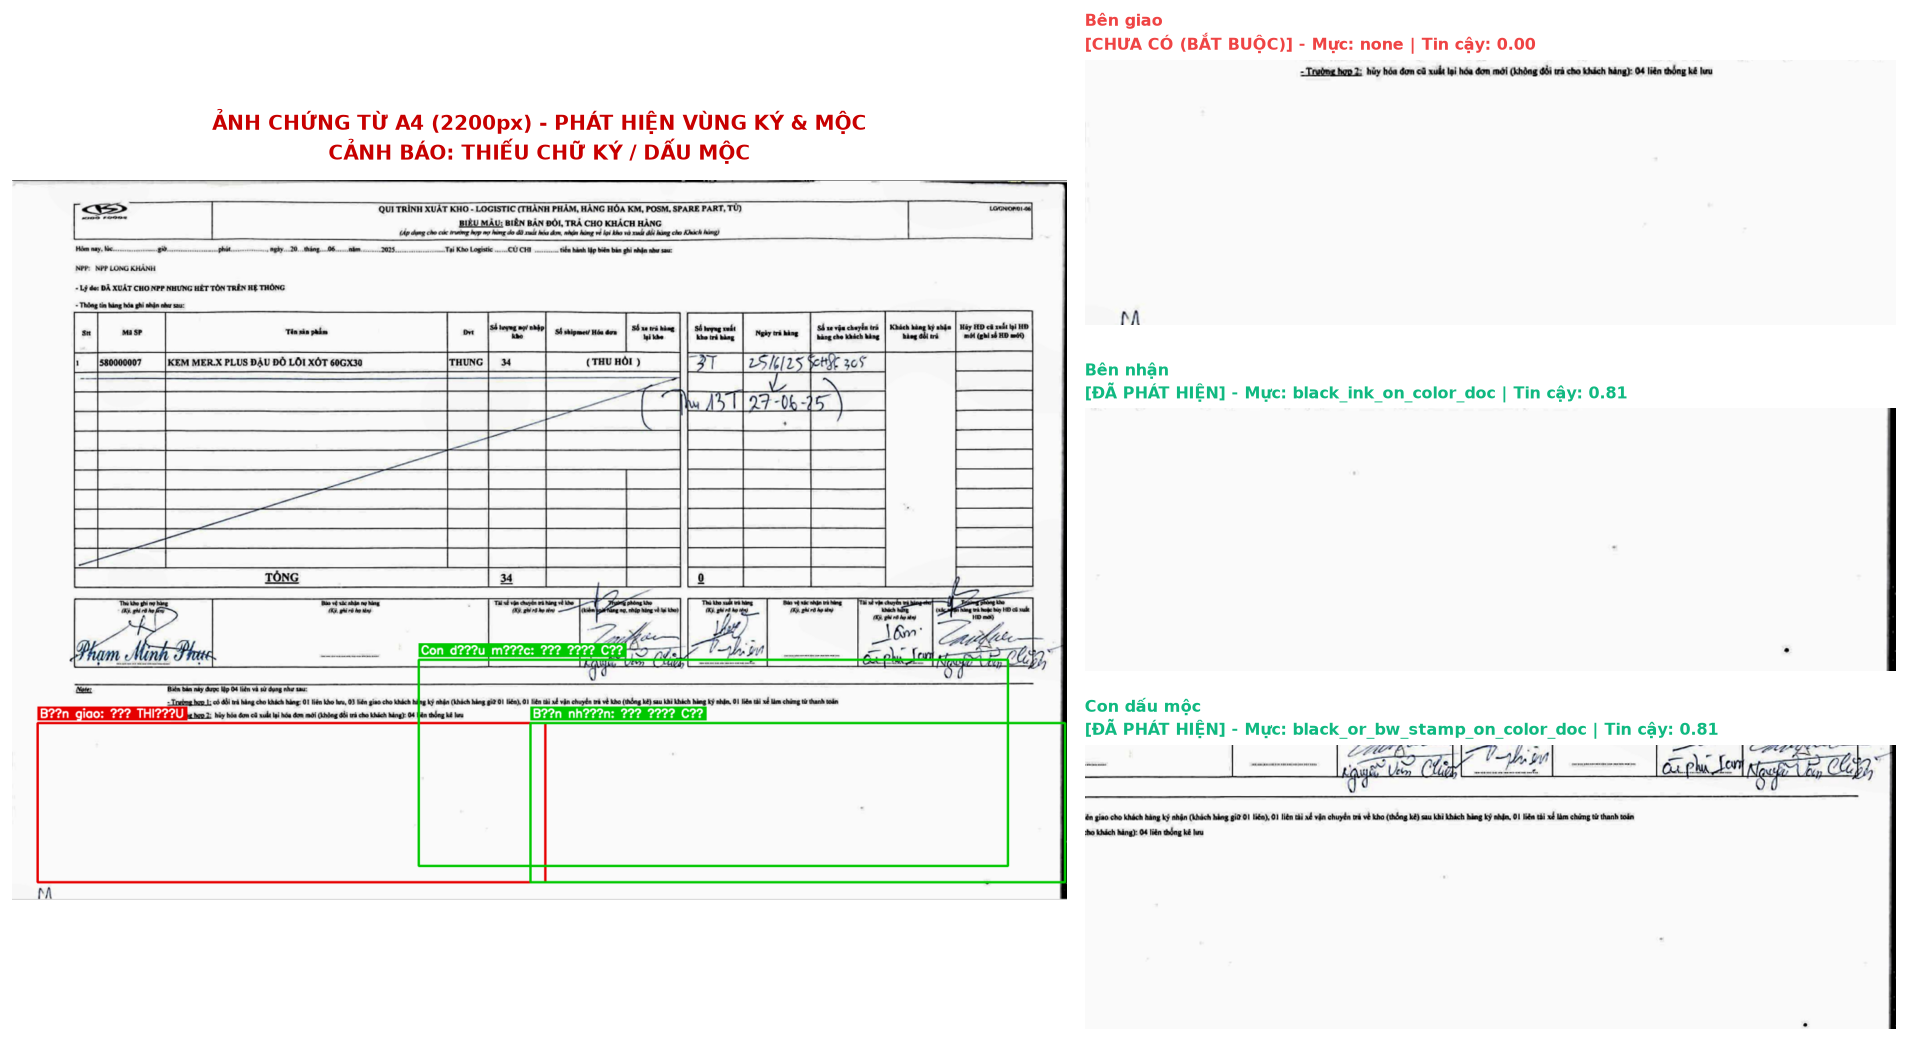

In [6]:
res_case3 = pipeline.process_document("output/form_samples/BB_NO_HANG__0.png")
display_audit_dashboard(res_case3, title="CA 3: BIÊN BẢN NỢ HÀNG")

### Ca 4: Loading Plan — zone động Tầng 3b
- **Tầng 3b:** dò đáy bảng + cột theo nhãn chức danh (mép đáy/mép ngoài per-column). Contract: `PAGE_1_NO_SIGNATURES` → `TRANG_1_CHUA_KY` / HOP_LE; zone ABSTAIN (`TABLE_ANCHOR_NOT_FOUND`, `COLUMN_*`) → `CHUA_CHUAN_HOA_VUNG_KY` / ABSTAIN — **không bao giờ** thành “không yêu cầu ký”.
- **Tầng 4:** chấm từng ô trên box động bằng **Tầng 4 ver2** (`tools/stage4_verifier_v2.py`, ngưỡng theo mm, `evaluate_document_verdict_v2`) — cùng engine sinh manifest ver2; kết quả ghi `engine = "v2"`. Các biểu mẫu preset tĩnh vẫn dùng v1 (`engine = "v1"`). Phán quyết **in ở output**. Phán quyết nhạy với cờ `required` của `Người nhận hàng` / `Người lập phiếu` (chờ quyết định nghiệp vụ, AGENTS.md 9.10.E).

📋 CA 4: LOADING PLAN - ZONE ĐỘNG TẦNG 3B
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Bảng kê xếp hàng (Loading Plan) (LOADING_PLAN)
   • Hệ thống / Đối tác: INTERNAL_KHO_NOIBO
   • Số Hóa đơn:        Không có
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): 120562
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        ĐẠT CHUẨN (BẢN GỐC CÓ MÀU)
   • Nội dung kết luận: Chứng từ có đầy đủ 3/3 vị trí chữ ký & con dấu mộc đỏ/xanh chuẩn màu thực tế.
   • Action vận hành:   DUYET  | zone_status: TABLE_BOTTOM_DETECTED  | engine Tầng 4: v2
   • Định dạng tài liệu: TRUE_COLOR | Vị trí đạt: 3/3 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   [1] Người lập phiếu                | ✓ ĐÃ CÓ    | Tùy chọn   | Mực: blue_ink                  | Engine: V2_SIGNATURE_MM
   [2] T

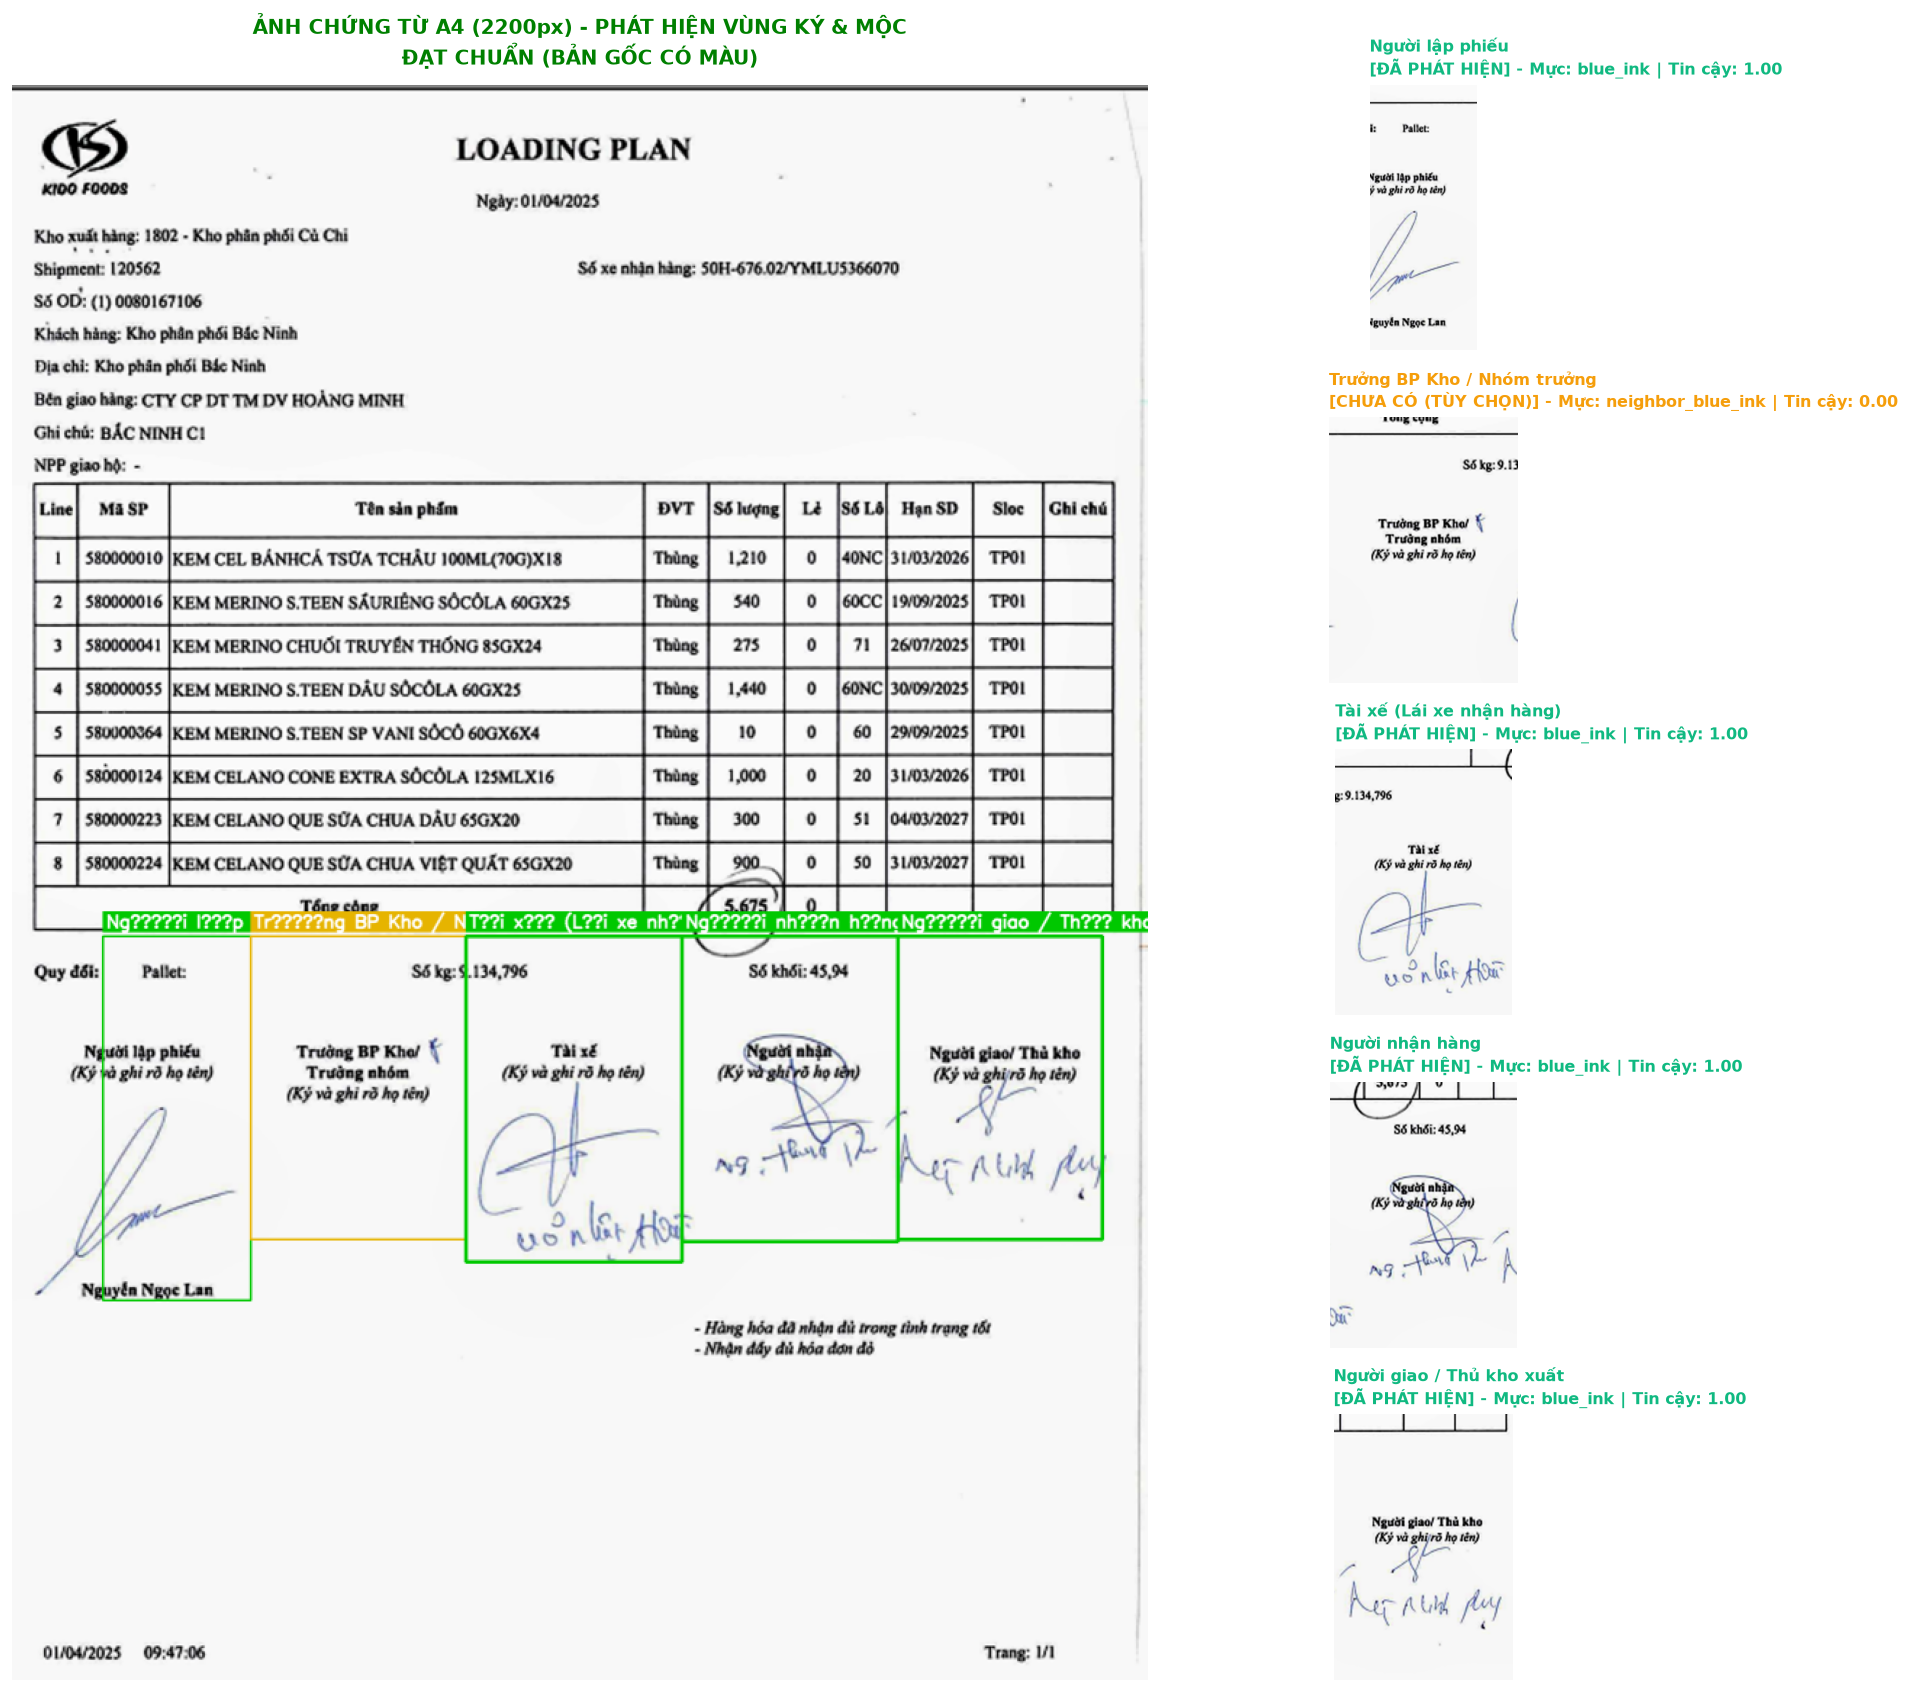

In [7]:
res_case4 = pipeline.process_document("output/form_samples/Loading_Plan_5.2__0.png")
display_audit_dashboard(res_case4, title="CA 4: LOADING PLAN - ZONE ĐỘNG TẦNG 3B")

### Ca 5: Biểu đồ nhiệt độ thùng lạnh (SOP không yêu cầu ký)
- **Đặc điểm:** biểu đồ xuất từ datalogger thùng xe đông lạnh.
- **Contract kỳ vọng:** theo SOP biểu mẫu này không cần chữ ký → `KHONG_YEU_CAU` / action `HOP_LE`. Khác hẳn `UNMAPPED` (chưa có cấu hình) — BUG-T4-02, AGENTS.md 7.A.7.

📋 CA 5: BIỂU ĐỒ NHIỆT ĐỘ - THEO QUY CHUẨN SOP KHÔNG YÊU CẦU KÝ
1. PHÂN LOẠI CHỨNG TỪ:
   • Tên biểu mẫu:      Biểu đồ ghi nhiệt độ thùng lạnh (SOP) (BIEU_DO_NHIET_DO)
   • Hệ thống / Đối tác: COMMON
   • Số Hóa đơn:        Không có
   • Số Đơn hàng (PO):  Không có
   • Mã chuyến xe (SAP): Không có
   • Phiếu xuất kho:    Không có
------------------------------------------------------------------------------------------
2. KẾT QUẢ KIỂM TRA CHỮ KÝ & CON DẤU MỘC:
   • Phán quyết:        KHÔNG YÊU CẦU KÝ ĐÓNG DẤU
   • Nội dung kết luận: Biểu mẫu này theo quy chuẩn SOP KIDO không bắt buộc phải có chữ ký hay con dấu.
   • Action vận hành:   HOP_LE  | zone_status: None  | engine Tầng 4: v1
   • Định dạng tài liệu: PHOTOCOPY_BW | Vị trí đạt: 0/0 bắt buộc
------------------------------------------------------------------------------------------
3. BẢNG CHI TIẾT TỪNG VỊ TRÍ:
   (Thời gian xử lý E2E toàn bộ 4 tầng: 7.93 giây)



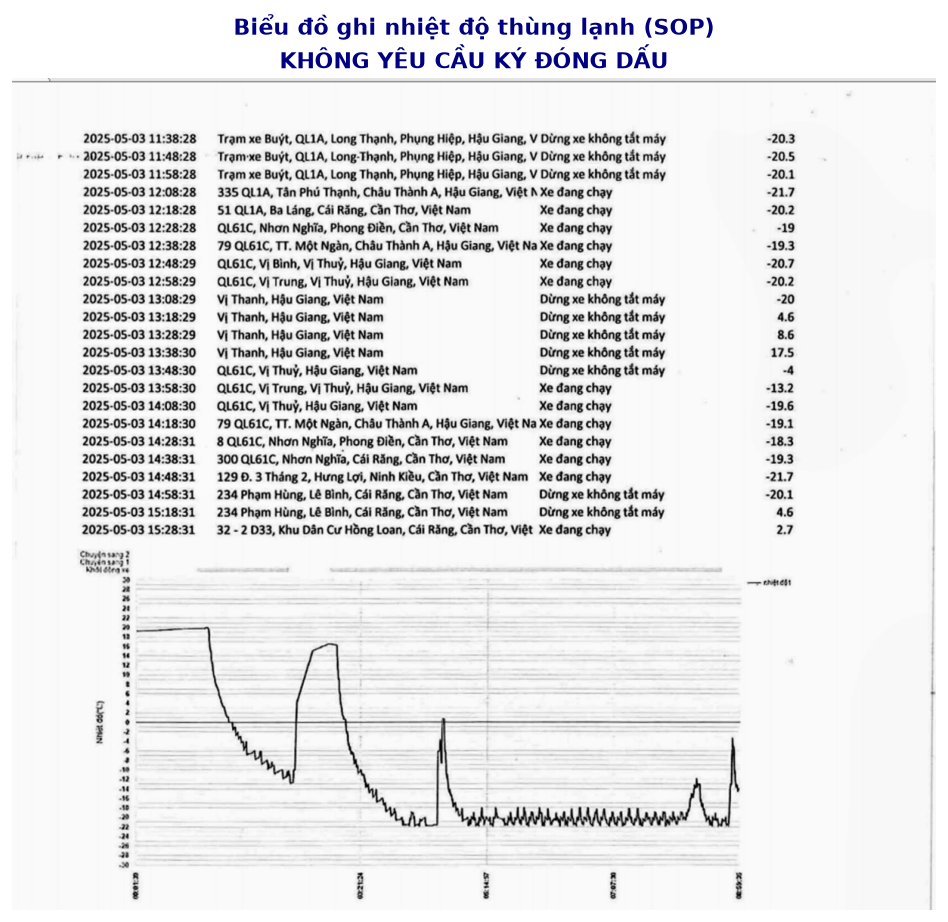

In [8]:
res_case5 = pipeline.process_document("output/form_samples/Bieu_do_nhiet_do__0.png")
display_audit_dashboard(res_case5, title="CA 5: BIỂU ĐỒ NHIỆT ĐỘ - THEO QUY CHUẨN SOP KHÔNG YÊU CẦU KÝ")

### Ca 6: Ảnh trắng — gác cổng Tầng 1
- **Đặc điểm:** ảnh giấy trắng **tổng hợp** (numpy, seed cố định). Bản trước dùng `THU_HOI_4.2__0.png` và gọi là "ảnh trắng" — SAI: ảnh đó có nội dung, Tầng 1 từ chối oan do đo mực trên mặt nạ giấy rác; đã sửa ở Tầng 1 (27/09).
- **Contract kỳ vọng:** Tầng 1 trả `CHUP_LAI`, pipeline dừng sớm với `YEU_CAU_CHUP_LAI`, không chạy các tầng sau.

In [9]:
import numpy as np
_rng6 = np.random.default_rng(20250927)
_blank = np.clip(_rng6.normal(242, 3, size=(2200, 1556, 3)), 0, 255).astype(np.uint8)
res_case6 = pipeline.process_document(_blank, file_name="synthetic_blank_page.png")
display_audit_dashboard(res_case6, title="CA 6: ẢNH LỖI / TRẮNG - GÁC CỔNG TẦNG 1 YÊU CẦU CHỤP LẠI")

❌ [GÁC CỔNG TẦNG 1] TỪ CHỐI CHỨNG TỪ: synthetic_blank_page.png
Trạng thái: YÊU CẦU CHỤP LẠI (Ảnh không đạt tiêu chuẩn kỹ thuật)
 • Lý do: Ảnh quá mờ (độ nét 13 < 25) — giữ máy ổn định và chụp lại
 • Lý do: Gần như không thấy nét chữ nào (0.00% diện tích) — ảnh trắng, chụp nhầm mặt sau hoặc cháy sáng hoàn toàn
 • Cảnh báo: Ảnh scan: không tách được biên tờ giấy, sẽ cắt viền trắng theo nội dung
Thời gian kiểm định dừng sớm: 1.92s



---
## 4. Bảng Tổng Hợp Kiểm Toán Hàng Loạt (Batch Audit Summary)
Khảo sát chạy liên hoàn trên 10 chứng từ đại diện cho các kênh và nhóm khác nhau, xuất bảng tổng hợp đối soát dành cho bộ phận kế toán và kiểm soát nội bộ KIDO:

In [10]:
import time
audit_samples = [
    "output/form_samples/Hoadon2.2__0.png",
    "output/form_samples/Hoadon_3.2__0.png",
    "output/form_samples/PGH3.6__0.png",
    "output/form_samples/PGH_3.8__0.png",
    "output/form_samples/BB_NO_HANG__0.png",
    "output/form_samples/BBBGHH_5.1__0.png",
    "output/form_samples/Loading_Plan_5.2__0.png",
    "output/form_samples/Loading_Plan2.1__0.png",
    "output/form_samples/Bieu_do_nhiet_do__0.png",
    "output/form_samples/THU_HOI_4.2__0.png"
]

records = []
t_total_start = time.time()

for sample_p in audit_samples:
    fn = Path(sample_p).name
    r = pipeline.process_document(sample_p)
    s2 = r.get("stage2", {})
    s4 = r.get("stage4", {})
    kf = s2.get("key_fields", {})
    
    records.append({
        "Tên File": fn,
        "Loại Chứng Từ": s2.get("doc_type_vi", s2.get("doc_type")),
        "Hệ Thống": s2.get("system"),
        "Số HĐ": kf.get("invoice_no") or "-",
        "Số PO": kf.get("po_no") or "-",
        "Mã Chuyến SAP": kf.get("shipment_id") or "-",
        "Định Dạng": s4.get("document_modality", "-"),
        "Vị Trí Đạt": f"{s4.get('detected_required_targets', 0)}/{s4.get('total_required_targets', 0)}",
        "Phán Quyết": s4.get("overall_verdict", r.get("status")),
        "Engine T4": r.get("engine") or "-",
        "Action": s4.get("action", r.get("status")),
        "zone_status": r.get("stage3", {}).get("zone_status") or "-",
        "Thời Gian (s)": r.get("elapsed_sec")
    })

t_total_elapsed = time.time() - t_total_start
df_audit = pd.DataFrame(records)

print(f"✓ Đã hoàn thành kiểm toán {len(audit_samples)} chứng từ trong {t_total_elapsed:.2f} giây (Trung bình {t_total_elapsed/len(audit_samples):.2f}s/chứng từ)\n")
df_audit

✓ Đã hoàn thành kiểm toán 10 chứng từ trong 57.14 giây (Trung bình 5.71s/chứng từ)



,Tên File,Loại Chứng Từ,Hệ Thống,Số HĐ,Số PO,Mã Chuyến SAP,Định Dạng,Vị Trí Đạt,Phán Quyết,Engine T4,Action,zone_status,Thời Gian (s)
0,Hoadon2.2__0.png,Hóa đơn giá trị gia tăng / Bán lẻ,GT,00044085,-,-,TRUE_COLOR,0/0,UNMAPPED,-,ABSTAIN,HOA_DON_ZONE_DEFERRED,5.763
1,Hoadon_3.2__0.png,Hóa đơn giá trị gia tăng / Bán lẻ,MT_COOP,00053432,-,133870,PHOTOCOPY_BW,0/0,UNMAPPED,-,ABSTAIN,HOA_DON_ZONE_DEFERRED,6.656
2,PGH3.6__0.png,Phiếu nhập kho kiêm tiếp nhận (PNK),MT_WINMART,-,-,-,PHOTOCOPY_BW,3/3,DAT_CHUAN_PHOTO,v1,DUYET,-,4.679
3,PGH_3.8__0.png,Phiếu giao nhận hàng (PGH),MT_GS25,-,WH0009250519944278,-,PHOTOCOPY_BW,1/2,THIEU_MOT_SO_CHU_KY,v1,CANH_BAO,-,5.208
4,BB_NO_HANG__0.png,Biên bản nợ hàng,COMMON,-,-,-,TRUE_COLOR,2/3,THIEU_MOT_SO_CHU_KY,v1,CANH_BAO,-,4.588
5,BBBGHH_5.1__0.png,Biên bản bàn giao hàng hóa,INTERNAL_TRANSFER,-,-,-,TRUE_COLOR,3/3,DAT_CHUAN_GOC,v1,DUYET,-,5.304
6,Loading_Plan_5.2__0.png,Bảng kê xếp hàng (Loading Plan),INTERNAL_KHO_NOIBO,-,-,120562,TRUE_COLOR,3/3,DAT_CHUAN_GOC,v2,DUYET,TABLE_BOTTOM_DETECTED,7.760
7,Loading_Plan2.1__0.png,Bảng kê xếp hàng (Loading Plan),GT,-,-,-,TRUE_COLOR,3/3,DAT_CHUAN_GOC,v2,DUYET,TABLE_BOTTOM_DETECTED,5.357
8,Bieu_do_nhiet_do__0.png,Biểu đồ ghi nhiệt độ thùng lạnh (SOP),COMMON,-,-,-,PHOTOCOPY_BW,0/0,KHONG_YEU_CAU,v1,HOP_LE,-,7.795
9,THU_HOI_4.2__0.png,Biên bản thu hồi chứng từ / hàng hóa,GT,-,-,-,TRUE_COLOR,3/3,DAT_CHUAN_GOC,v1,DUYET,-,4.019


---
## 5. Kết Luận & Hướng Dẫn Tích Hợp Hệ Thống Sản Xuất

Pipeline hợp nhất thực hiện 2 nhiệm vụ:
1. **Phân loại chứng từ** và bóc tách trường định danh (`invoice_no`, `po_no`, `shipment_id`, …) — chỉ số đo ở `output/stage2_out/stage2_benchmark_report.json`.
2. **Kiểm tra chữ ký / mộc** theo contract hiện tại: preset tĩnh (engine v1) cho biểu mẫu có cấu hình; zone động Tầng 3b + engine **ver2** cho `LOADING_PLAN`; `HOA_DON` hoãn (ABSTAIN). Mọi ABSTAIN / `REVIEW_REQUIRED` phải chuyển người kiểm tra.

**Giới hạn đã biết:** latency dao động (TEST 9, AGENTS.md 9.3); Engine B có FP do đường kẻ bảng (7.E); engine chữ ký zone động chưa đo trên bút đen / ảnh BW (9.11.D).

### 🔌 Cách Thức Gọi Pipeline Trong Ứng Dụng (FastAPI / Web App / Batch Job):
```python
from tools.kido_pipeline import KidoDocumentPipeline

# Khởi tạo 1 lần duy nhất khi khởi động server
pipeline = KidoDocumentPipeline()

# Gọi xử lý chứng từ từ file path hoặc numpy array
result = pipeline.process_document("path/to/invoice.jpg")

# Trích xuất kết quả phân loại
doc_type = result["stage2"]["doc_type"]
invoice_no = result["stage2"]["key_fields"]["invoice_no"]

# Trích xuất kết quả kiểm tra con dấu & chữ ký
verdict = result["stage4"]["overall_verdict"]   # DAT_CHUAN_* / THIEU_MOT_SO_CHU_KY / CHUA_KY_DONG_DAU / TRANG_1_CHUA_KY /
                                                # CHUA_CHUAN_HOA_VUNG_KY / UNMAPPED / KHONG_YEU_CAU / ...
action = result["stage4"]["action"]             # DUYET / HOP_LE / CANH_BAO / YEU_CAU_KY_LAI / ABSTAIN / REVIEW_REQUIRED
engine = result["engine"]                       # "v2" (LOADING_PLAN) / "v1" (preset tĩnh) / None (không engine nào chạy)
is_accepted = action in ("DUYET", "HOP_LE")
needs_human = action in ("ABSTAIN", "REVIEW_REQUIRED", "CANH_BAO")
```